In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [76]:
df_severity = pd.read_csv("data/severity.csv")

In [77]:
df_frequency = pd.read_csv("data/frequency.csv")

In [78]:
df_severity.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimSizeMD
0,2009,Female,A,Medium,Housewife,41,0,24940,1,273,740
1,2009,Male,B,Small,Unemployed,25,12,48945,0,190,207
2,2009,Female,E,Small,Employed,29,7,1525,0,225,803
3,2009,Male,A,Small,Self-employed,47,12,18480,1,129,868
4,2009,Female,C,Large,Employed,47,7,8690,0,290,1746


In [79]:
df_severity.shape

(12256, 11)

In [80]:
df_severity.isna().any().sum()

np.int64(0)

Okay, there are no missing values in the data. So it's a good sign at least :)

In [81]:
df_severity.duplicated().any()

np.False_

and no duplicates :))

In [82]:
df_severity.info()

<class 'pandas.DataFrame'>
RangeIndex: 12256 entries, 0 to 12255
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uwYear       12256 non-null  int64
 1   gender       12256 non-null  str  
 2   carType      12256 non-null  str  
 3   carCat       12256 non-null  str  
 4   job          12256 non-null  str  
 5   age          12256 non-null  int64
 6   nYears       12256 non-null  int64
 7   carVal       12256 non-null  int64
 8   cover        12256 non-null  int64
 9   density      12256 non-null  int64
 10  claimSizeMD  12256 non-null  int64
dtypes: int64(7), str(4)
memory usage: 1.3 MB


In [83]:
convert_dtype_dict = {
    "gender": "category",
    "carType": "category",
    "carCat": "category",
    "job": "category",
}

In [84]:
df_severity = df_severity.astype(convert_dtype_dict)

In [85]:
df_severity.dtypes

uwYear            int64
gender         category
carType        category
carCat         category
job            category
age               int64
nYears            int64
carVal            int64
cover             int64
density           int64
claimSizeMD       int64
dtype: object

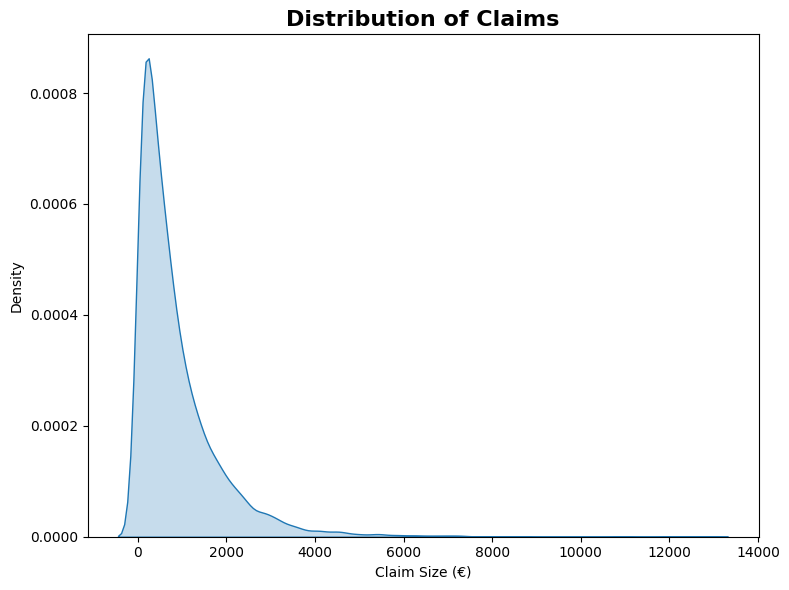

In [86]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(data=df_severity, ax=ax, x="claimSizeMD", fill=True)
ax.set_title("Distribution of Claims", fontweight="bold", fontsize=16)
ax.set(xlabel="Claim Size (€)")

fig.tight_layout()

the distribution of claim sizes is right-skewed. so let's see how does a log transform of them make it. but for the statistical tests it is better to use a non-parametric test.

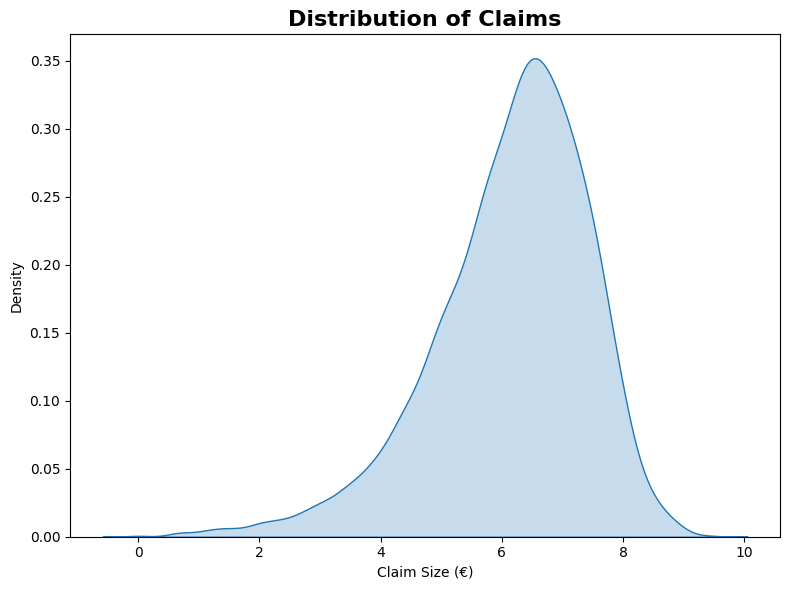

In [87]:
log_claim_size = np.log1p(df_severity["claimSizeMD"])

fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(ax=ax, x=log_claim_size, fill=True)
ax.set_title("Distribution of Claims", fontweight="bold", fontsize=16)
ax.set(xlabel="Claim Size (€)")

fig.tight_layout()

so yeah the log transform makes it kinda normally distributed. maybe we can use this fact in the model building process.

In [88]:
df_frequency.head()

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD
0,2009,Male,C,Large,Employed,25,3,15080,0,72.012883,1
1,2009,Male,E,Large,Employed,20,2,22370,1,39.550411,1
2,2009,Female,E,Large,Unemployed,42,0,39650,0,169.529148,1
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1
4,2009,Female,D,Large,Employed,33,10,9065,0,109.631885,1


In [105]:
df_frequency.shape

(24753, 11)

In [89]:
df_frequency.isna().any().sum()

np.int64(0)

In [90]:
df_frequency[df_frequency.duplicated(keep=False)].sort_values(
    by=list(df_frequency.columns)
)

,uwYear,gender,carType,carCat,job,age,nYears,carVal,cover,density,claimNumbMD
11,2009,Female,A,Large,Housewife,65,15,11880,0,223.308572,1
46,2009,Female,A,Large,Housewife,65,15,11880,0,223.308572,1
12,2009,Female,A,Medium,Unemployed,25,2,23130,0,107.817053,1
47,2009,Female,A,Medium,Unemployed,25,2,23130,0,107.817053,1
15,2009,Female,A,Small,Employed,29,0,11370,0,32.212556,1
50,2009,Female,A,Small,Employed,29,0,11370,0,32.212556,1
7,2009,Female,B,Medium,Employed,29,12,8965,0,272.966995,1
42,2009,Female,B,Medium,Employed,29,12,8965,0,272.966995,1
3,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1
38,2009,Female,C,Medium,Housewife,21,0,12600,1,58.894688,1


so there are these duplicates, and even though we don't have a unique identifier, I think it's safe to drop them because it is highly unlikely to have these very similar rows.

In [91]:
df_frequency.drop_duplicates(inplace=True)

In [92]:
df_frequency.info()

<class 'pandas.DataFrame'>
Index: 24753 entries, 0 to 24773
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uwYear       24753 non-null  int64  
 1   gender       24753 non-null  str    
 2   carType      24753 non-null  str    
 3   carCat       24753 non-null  str    
 4   job          24753 non-null  str    
 5   age          24753 non-null  int64  
 6   nYears       24753 non-null  int64  
 7   carVal       24753 non-null  int64  
 8   cover        24753 non-null  int64  
 9   density      24753 non-null  float64
 10  claimNumbMD  24753 non-null  int64  
dtypes: float64(1), int64(6), str(4)
memory usage: 2.8 MB


In [93]:
df_frequency = df_frequency.astype(convert_dtype_dict)

In [94]:
df_frequency.dtypes

uwYear            int64
gender         category
carType        category
carCat         category
job            category
age               int64
nYears            int64
carVal            int64
cover             int64
density         float64
claimNumbMD       int64
dtype: object

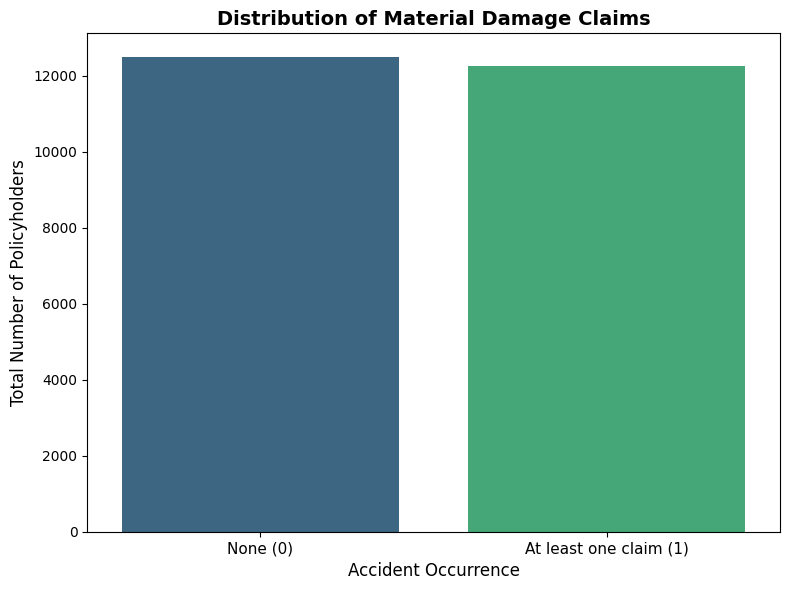

In [95]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.countplot(
    data=df_frequency, ax=ax, x="claimNumbMD", hue="claimNumbMD", palette="viridis", legend=False
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["None (0)", "At least one claim (1)"], fontsize=11)

ax.set_title("Distribution of Material Damage Claims", fontweight="bold", fontsize=14)
ax.set_xlabel("Accident Occurrence", fontsize=12)
ax.set_ylabel("Total Number of Policyholders", fontsize=12)

fig.tight_layout()

## Exploring `gender`

In [96]:
df_severity["gender"].value_counts()

gender
Male      8343
Female    3913
Name: count, dtype: int64

In [97]:
df_severity.groupby("gender")["carCat"].value_counts().reset_index()

,gender,carCat,count
0,Female,Medium,1476
1,Female,Small,1258
2,Female,Large,1179
3,Male,Medium,3039
4,Male,Small,2910
5,Male,Large,2394


In [98]:
df_severity.groupby("gender")["job"].value_counts().reset_index()

,gender,job,count
0,Female,Employed,1311
1,Female,Housewife,939
2,Female,Unemployed,816
3,Female,Self-employed,699
4,Female,Retired,148
5,Male,Employed,2984
6,Male,Housewife,1981
7,Male,Unemployed,1673
8,Male,Self-employed,1389
9,Male,Retired,316


In [99]:
df_severity.groupby("gender")[["age", "nYears", "carVal", "claimSizeMD"]].agg(
    "mean"
).round(decimals=2)

,age,nYears,carVal,claimSizeMD
gender,,,,
Female,35.64,5.02,16958.56,792.46
Male,34.68,4.97,17187.14,900.73


In [100]:
df_severity.groupby("gender")["claimSizeMD"].median()

gender
Female    508.0
Male      581.0
Name: claimSizeMD, dtype: float64

so men tend to have a larger claim size. but let's run a statistical test to see if it's actually significant.

In [101]:
female_claims = df_severity[df_severity["gender"] == "Female"]["claimSizeMD"]
male_claims = df_severity[df_severity["gender"] == "Male"]["claimSizeMD"]

In [102]:
u_stat, p_value = stats.mannwhitneyu(male_claims, female_claims)

In [103]:
print(f"Mann-Whitney U statistic: {u_stat:.2f}")
print(f"p-value: {p_value:.4f}")

Mann-Whitney U statistic: 17455144.50
p-value: 0.0000


In [104]:
df_frequency["gender"].value_counts()

gender
Male      16289
Female     8464
Name: count, dtype: int64

the men make claims twice as much as women. and it's consistent with the result we got from the severity data set

In [107]:
df_frequency.groupby("gender")["claimNumbMD"].value_counts().reset_index()

,gender,claimNumbMD,count
0,Female,0,4551
1,Female,1,3913
2,Male,1,8343
3,Male,0,7946


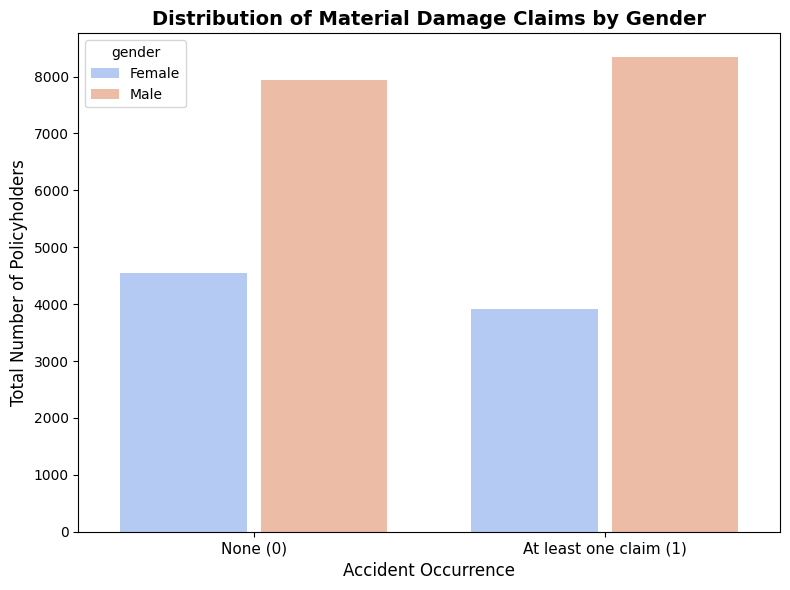

In [110]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.countplot(data=df_frequency, ax=ax, x="claimNumbMD", hue="gender", palette="coolwarm", gap=0.1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["None (0)", "At least one claim (1)"], fontsize=11)

ax.set_title("Distribution of Material Damage Claims by Gender", fontweight="bold", fontsize=14)
ax.set_xlabel("Accident Occurrence", fontsize=12)
ax.set_ylabel("Total Number of Policyholders", fontsize=12)

fig.tight_layout()

again very consistent with the results we got from the severity data

so gender is definitely one of the important factors in both severity and frequency